# DRL01 Temporal-Difference Learning

### Lab Description

This laboratory introduces **temporal-difference (TD) learning** with Gymnasium. We first inspect `MiniGrid-Empty-8x8-v0`, establish random and heuristic baselines, and use **TD(0)** for policy evaluation. We then implement three one-step tabular control methods (**SARSA**, **Expected SARSA**, and **Q-learning**) from first principles with NumPy.

Two case studies broaden the workflow. Gymnasium Taxi shows how the same tabular update operates on an integer state space, while MiniGrid BlockedUnlockPickup demonstrates potential-based reward shaping for a sparse-reward task. Every learning method in this tutorial represents values explicitly in a table.

Visualizations include native environment frames, animated GIF rollouts, value and policy heatmaps, and matched learning curves.

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (for example, Ryzen™ AI Max+ PRO 395 or Ryzen™ AI Max 390). All sections run on the CPU.

#### Software Environment

OS: Ubuntu 24.04 LTS  
Python 3.12 with Gymnasium, MiniGrid, NumPy, Matplotlib, and ImageIO in the [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html?family=ryzen-ai&gpu=max-pro-395) environment.

## Goals

- Use Gymnasium's `reset()`, `step()`, `terminated`, and `truncated` interfaces
- Interpret MiniGrid's observations, relative actions, position, and direction
- Explain bootstrapping and compute a one-step TD error
- Estimate state values with TD(0)
- Implement SARSA, Expected SARSA, and Q-learning with ε-greedy exploration
- Distinguish on-policy and off-policy TD targets
- Decode Gymnasium Taxi states and train a tabular Taxi policy
- Design and evaluate intermediate rewards for a sparse-reward task
- Evaluate policies with return, success rate, episode length, heatmaps, and GIF rollouts

## 1. Setup

The setup cell installs only missing environment and visualization packages. All learning methods in this tutorial use NumPy tables and run on the CPU.

In [ ]:
import importlib.util
import os
import site
import subprocess
import sys


os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

required_packages = {
    "gymnasium": "gymnasium",
    "minigrid": "minigrid",
    "imageio": "imageio",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--user",
            "--quiet",
            "--no-warn-script-location",
            *missing_packages,
        ]
    )
    site.addsitedir(site.getusersitepackages())

from dataclasses import dataclass
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
import minigrid
import numpy as np
from IPython.display import Image, display

print("Python:", sys.version.split()[0])
print("Gymnasium:", gym.__version__)
print("MiniGrid:", minigrid.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

In [ ]:
SEED = 7
ENV_NAME = "MiniGrid-Empty-8x8-v0"
ARTIFACT_DIR = Path("artifacts") / "DRL01"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)

print("Artifacts:", ARTIFACT_DIR.resolve())


def make_env(render_mode=None):
    return gym.make(ENV_NAME, render_mode=render_mode)

## 2. Understanding the MiniGrid Environment

MiniGrid is a lightweight collection of grid-based reinforcement-learning environments. In `MiniGrid-Empty-8x8-v0`, the agent starts near the upper-left corner and must navigate to the green goal tile near the lower-right corner.

The standard Gymnasium interaction loop is:

```python
observation, info = env.reset(seed=...)
observation, reward, terminated, truncated, info = env.step(action)
```

- `terminated=True` means the task's terminal condition was reached.
- `truncated=True` means an external limit, such as the maximum episode length, stopped the episode.
- MiniGrid's `image` observation is an egocentric symbolic view.
- `direction` uses `0=right`, `1=down`, `2=left`, and `3=up`.

For this empty, fully known layout, a compact tabular state `(agent_x, agent_y, direction)` is sufficient for learning useful navigation behavior and follows the state design in the reference notebook.

Environment: MiniGrid-Empty-8x8-v0
Action space: Discrete(7)
Observation keys: ('image', 'direction', 'mission')
Image observation shape: (7, 7, 3)
Mission: get to the green goal square
Agent position: (1, 1)
Agent direction: 0
Grid size: (8, 8)


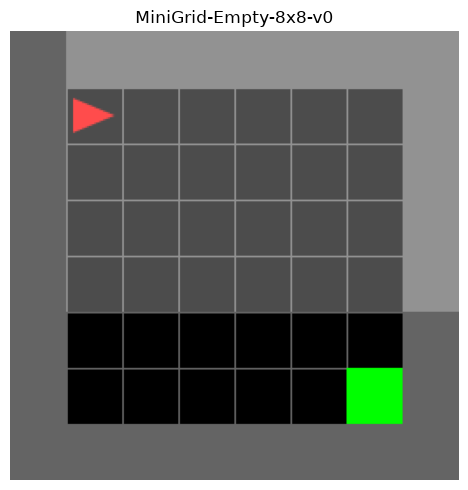

In [3]:
preview_env = make_env(render_mode="rgb_array")
observation, info = preview_env.reset(seed=SEED)
base_env = preview_env.unwrapped

print("Environment:", ENV_NAME)
print("Action space:", preview_env.action_space)
print("Observation keys:", tuple(observation.keys()))
print("Image observation shape:", observation["image"].shape)
print("Mission:", observation["mission"])
print("Agent position:", tuple(base_env.agent_pos))
print("Agent direction:", base_env.agent_dir)
print("Grid size:", (base_env.width, base_env.height))

initial_frame = preview_env.render()
plt.figure(figsize=(5, 5))
plt.imshow(initial_frame)
plt.axis("off")
plt.title("MiniGrid-Empty-8x8-v0")
plt.tight_layout()
plt.show()

### 2.1 Relative navigation actions

MiniGrid exposes seven actions because other environments contain objects, doors, and keys. The empty navigation task needs only three:

| Table index | MiniGrid action | Effect |
|---:|---|---|
| 0 | `left` | Rotate 90° counter-clockwise |
| 1 | `right` | Rotate 90° clockwise |
| 2 | `forward` | Move one cell in the facing direction |

Restricting the Q-table to relevant actions reduces unnecessary exploration while all interactions still go through the original MiniGrid environment.

In [4]:
actions_enum = base_env.actions
NAV_ACTIONS = np.asarray(
    [int(actions_enum.left), int(actions_enum.right), int(actions_enum.forward)],
    dtype=int,
)
ACTION_NAMES = ("left", "right", "forward")
ACTION_SYMBOLS = ("↺", "↻", "↑")
DIRECTION_SYMBOLS = ("→", "↓", "←", "↑")


def get_agent_state(env):
    '''Return the compact tabular state (x, y, direction).'''
    unwrapped = env.unwrapped
    x, y = map(int, unwrapped.agent_pos)
    return x, y, int(unwrapped.agent_dir)


def find_object_position(env, object_type):
    grid = env.unwrapped.grid
    for x in range(grid.width):
        for y in range(grid.height):
            obj = grid.get(x, y)
            if obj is not None and getattr(obj, "type", None) == object_type:
                return x, y
    raise ValueError(f"Object type {object_type!r} was not found")


GOAL_POSITION = find_object_position(preview_env, "goal")
print("Navigation action mapping:", dict(zip(range(len(NAV_ACTIONS)), ACTION_NAMES)))
print("Initial compact state:", get_agent_state(preview_env))
print("Goal position:", GOAL_POSITION)
preview_env.close()

Navigation action mapping: {0: 'left', 1: 'right', 2: 'forward'}
Initial compact state: (1, 1, 0)
Goal position: (6, 6)


### 2.2 Random-agent baseline and GIF visualization

A random agent verifies the complete environment loop and provides a baseline. Frames returned by `render_mode="rgb_array"` are collected into an animated GIF.

Random agent: reward=0.000, steps=80, success=False


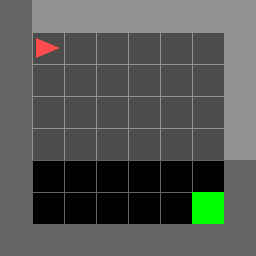

In [5]:
def random_agent_rollout(seed=0, max_steps=80, gif_path=None):
    env = make_env(render_mode="rgb_array")
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    frames = [env.render().copy()]
    total_reward = 0.0
    terminated = truncated = False

    for _ in range(max_steps):
        local_action = int(rng.integers(len(NAV_ACTIONS)))
        _, reward, terminated, truncated, _ = env.step(int(NAV_ACTIONS[local_action]))
        total_reward += float(reward)
        frames.append(env.render().copy())
        if terminated or truncated:
            break

    env.close()
    if gif_path is not None:
        imageio.mimsave(gif_path, frames, fps=6, loop=0)
    return total_reward, len(frames) - 1, bool(terminated)


random_gif = ARTIFACT_DIR / "minigrid_random_agent.gif"
random_return, random_steps, random_success = random_agent_rollout(
    seed=SEED,
    max_steps=80,
    gif_path=random_gif,
)
print(f"Random agent: reward={random_return:.3f}, steps={random_steps}, success={random_success}")
display(Image(filename=str(random_gif)))

## 3. From Returns to Temporal-Difference Learning

At time $t$, the agent observes $S_t$, selects $A_t$, receives $R_{t+1}$, and moves to $S_{t+1}$. The discounted return is

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots.
$$

Under policy $\pi$, the state value is $V_\pi(s)=\mathbb{E}_\pi[G_t\mid S_t=s]$. TD(0) learns before the episode finishes by bootstrapping from its current next-state estimate:

$$
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t),
$$

$$
V(S_t) \leftarrow V(S_t)+\alpha\delta_t.
$$

| Method | Needs a model? | Waits for episode end? | Bootstraps? |
|---|---:|---:|---:|
| Dynamic programming | Yes | No | Yes |
| Monte Carlo | No | Yes | No |
| TD(0) | No | No | Yes |

### 3.1 A fixed goal-directed policy

Policy evaluation keeps the policy fixed. The heuristic below uses position and direction to face the goal and then move forward. It remains ε-soft, so every navigation action has nonzero probability and TD observes a variety of transitions.

In [6]:
def desired_direction(state, goal_position):
    x, y, _ = state
    goal_x, goal_y = goal_position
    delta_x, delta_y = goal_x - x, goal_y - y

    if abs(delta_x) >= abs(delta_y) and delta_x != 0:
        return 0 if delta_x > 0 else 2
    if delta_y != 0:
        return 1 if delta_y > 0 else 3
    return state[2]


def goal_directed_probabilities(state, goal_position, exploration=0.20):
    desired = desired_direction(state, goal_position)
    direction = state[2]
    rotation = (desired - direction) % 4

    if rotation == 0:
        greedy_action = 2  # forward
    elif rotation == 1:
        greedy_action = 1  # turn right
    elif rotation == 3:
        greedy_action = 0  # turn left
    else:
        greedy_action = 1  # either turn is equally short; choose right consistently

    probabilities = np.full(len(NAV_ACTIONS), exploration / len(NAV_ACTIONS), dtype=float)
    probabilities[greedy_action] += 1.0 - exploration
    return probabilities


sample_state = (1, 1, 0)
print("Sample state:", sample_state)
print("Policy probabilities:", dict(zip(ACTION_NAMES, goal_directed_probabilities(sample_state, GOAL_POSITION))))

Sample state: (1, 1, 0)
Policy probabilities: {'left': np.float64(0.06666666666666667), 'right': np.float64(0.06666666666666667), 'forward': np.float64(0.8666666666666667)}


### 3.2 A numerical TD update

Suppose $V(S_t)=0.20$, $R_{t+1}=0$, and $V(S_{t+1})=0.35$. With $\gamma=0.99$ and $\alpha=0.10$:

In [7]:
current_value = 0.20
reward = 0.0
next_value = 0.35
gamma = 0.99
alpha = 0.10

td_target = reward + gamma * next_value
td_error = td_target - current_value
updated_value = current_value + alpha * td_error

print(f"TD target : {td_target:.4f}")
print(f"TD error  : {td_error:.4f}")
print(f"New value : {updated_value:.4f}")

TD target : 0.3465
TD error  : 0.1465
New value : 0.2147


### 3.3 TD(0) policy evaluation in MiniGrid

Values are stored as `V[x, y, direction]`. Only `terminated` removes the bootstrap term. A time-limit `truncated` transition ends the rollout but still bootstraps because the successor state is not an MDP terminal state.

In [8]:
def td0_prediction(
    episodes=3000,
    alpha=0.08,
    gamma=0.99,
    exploration=0.20,
    seed=0,
):
    env = make_env()
    env.reset(seed=seed)
    width, height = env.unwrapped.width, env.unwrapped.height
    start_x, start_y, _ = get_agent_state(env)
    values = np.zeros((width, height, 4), dtype=float)
    visits = np.zeros_like(values, dtype=int)
    start_value_history = []
    rng = np.random.default_rng(seed)
    goal_position = find_object_position(env, "goal")

    for episode in range(episodes):
        env.reset(seed=seed + episode)
        state = get_agent_state(env)

        while True:
            probabilities = goal_directed_probabilities(state, goal_position, exploration)
            local_action = int(rng.choice(len(NAV_ACTIONS), p=probabilities))
            _, reward, terminated, truncated, _ = env.step(int(NAV_ACTIONS[local_action]))
            next_state = get_agent_state(env)

            bootstrap = 0.0 if terminated else gamma * values[next_state]
            td_target = float(reward) + bootstrap
            values[state] += alpha * (td_target - values[state])
            visits[state] += 1

            state = next_state
            if terminated or truncated:
                break

        start_value_history.append(float(np.mean(values[start_x, start_y, :])))

    env.close()
    return values, visits, np.asarray(start_value_history)


td_values, td_visits, td_start_history = td0_prediction(seed=SEED)
print("Mean estimated value at the start:", round(float(np.mean(td_values[1, 1, :])), 4))
print("Visited state-directions:", int(np.count_nonzero(td_visits)))

Mean estimated value at the start: 0.6442
Visited state-directions: 117


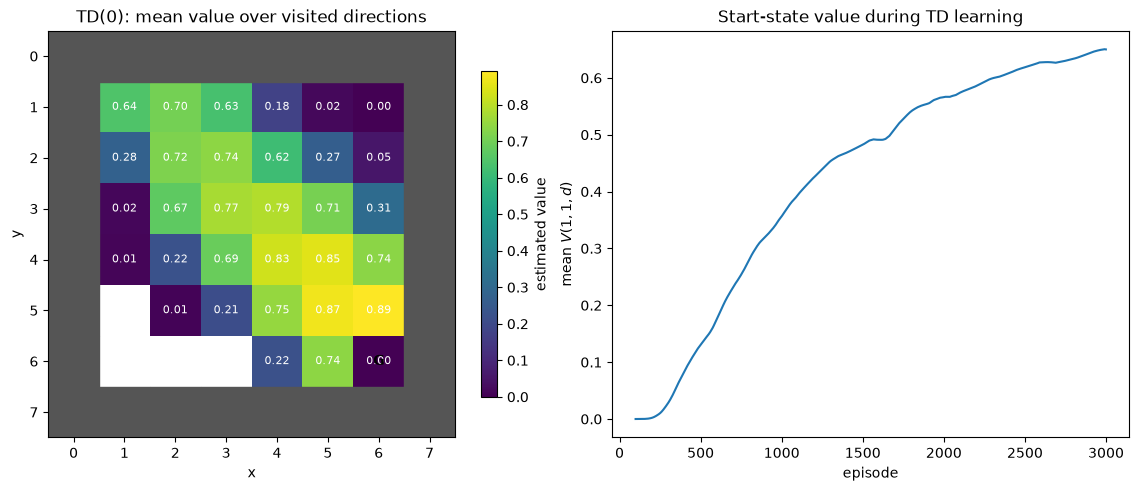

In [9]:
def layout_from_env(env):
    grid = env.unwrapped.grid
    walls = np.zeros((grid.height, grid.width), dtype=bool)
    goal = None
    for x in range(grid.width):
        for y in range(grid.height):
            obj = grid.get(x, y)
            obj_type = getattr(obj, "type", None) if obj is not None else None
            walls[y, x] = obj_type == "wall"
            if obj_type == "goal":
                goal = (x, y)
    return walls, goal


def aggregate_oriented_values(values, visits):
    width, height, _ = values.shape
    value_map = np.full((height, width), np.nan, dtype=float)
    for x in range(width):
        for y in range(height):
            observed_directions = visits[x, y, :] > 0
            if np.any(observed_directions):
                value_map[y, x] = float(np.mean(values[x, y, observed_directions]))
    return value_map


value_env = make_env()
value_env.reset(seed=SEED)
wall_mask, goal_position = layout_from_env(value_env)
value_map = aggregate_oriented_values(td_values, td_visits)
value_map[wall_mask] = np.nan
value_map[goal_position[1], goal_position[0]] = 0.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
image = axes[0].imshow(np.ma.masked_invalid(value_map), cmap="viridis", origin="upper")
for y in range(value_map.shape[0]):
    for x in range(value_map.shape[1]):
        if wall_mask[y, x]:
            axes[0].add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color="#555555"))
        elif np.isfinite(value_map[y, x]):
            axes[0].text(x, y, f"{value_map[y, x]:.2f}", ha="center", va="center", color="white", fontsize=8)
axes[0].text(goal_position[0], goal_position[1], "G", ha="center", va="center", weight="bold")
axes[0].set_title("TD(0): mean value over visited directions")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(image, ax=axes[0], shrink=0.8, label="estimated value")

window = 100
smooth_start = np.convolve(td_start_history, np.ones(window) / window, mode="valid")
axes[1].plot(np.arange(window - 1, len(td_start_history)), smooth_start)
axes[1].set_title("Start-state value during TD learning")
axes[1].set_xlabel("episode")
axes[1].set_ylabel("mean $V(1,1,d)$")
plt.show()
value_env.close()

## 4. One-Step TD Control

Policy evaluation asks how good a fixed policy is. Control learns action values and improves behavior.

### SARSA — on-policy

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t)+\alpha
[R_{t+1}+\gamma Q(S_{t+1},A_{t+1})-Q(S_t,A_t)].
$$

### Expected SARSA — on-policy expectation

$$
R_{t+1}+\gamma\sum_a\pi(a\mid S_{t+1})Q(S_{t+1},a).
$$

### Q-learning — off-policy

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t)+\alpha
[R_{t+1}+\gamma\max_a Q(S_{t+1},a)-Q(S_t,A_t)].
$$

| Algorithm | Nonterminal bootstrap target | Relationship |
|---|---|---|
| SARSA | $Q(S',A')$ | On-policy |
| Expected SARSA | $\sum_a\pi(a\mid S')Q(S',a)$ | On-policy |
| Q-learning | $\max_a Q(S',a)$ | Off-policy |

In [10]:
@dataclass
class TrainingResult:
    name: str
    q_values: np.ndarray
    episode_returns: np.ndarray
    episode_lengths: np.ndarray
    successes: np.ndarray
    epsilons: np.ndarray
    td_errors: np.ndarray


def epsilon_greedy_probabilities(action_values, epsilon):
    probabilities = np.full(len(action_values), epsilon / len(action_values), dtype=float)
    greedy_actions = np.flatnonzero(np.isclose(action_values, np.max(action_values)))
    probabilities[greedy_actions] += (1.0 - epsilon) / len(greedy_actions)
    return probabilities


def sample_epsilon_greedy(action_values, epsilon, rng):
    probabilities = epsilon_greedy_probabilities(action_values, epsilon)
    return int(rng.choice(len(action_values), p=probabilities))


def train_td_control(
    algorithm,
    episodes=2500,
    alpha=0.20,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.05,
    seed=0,
):
    valid_algorithms = {"sarsa", "expected_sarsa", "q_learning"}
    if algorithm not in valid_algorithms:
        raise ValueError(f"algorithm must be one of {sorted(valid_algorithms)}")

    env = make_env()
    env.reset(seed=seed)
    width, height = env.unwrapped.width, env.unwrapped.height
    q_values = np.zeros((width, height, 4, len(NAV_ACTIONS)), dtype=float)
    episode_returns = np.zeros(episodes, dtype=float)
    episode_lengths = np.zeros(episodes, dtype=int)
    successes = np.zeros(episodes, dtype=bool)
    epsilons = np.zeros(episodes, dtype=float)
    td_errors = []
    rng = np.random.default_rng(seed)

    for episode in range(episodes):
        progress = episode / max(1, episodes - 1)
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-5.0 * progress)
        epsilons[episode] = epsilon

        env.reset(seed=seed + episode)
        state = get_agent_state(env)
        action = sample_epsilon_greedy(q_values[state], epsilon, rng)
        total_reward = 0.0

        while True:
            _, reward, terminated, truncated, _ = env.step(int(NAV_ACTIONS[action]))
            done = terminated or truncated
            next_state = get_agent_state(env)

            if terminated:
                td_target = float(reward)
                next_action = None
            elif algorithm == "sarsa":
                next_action = sample_epsilon_greedy(q_values[next_state], epsilon, rng)
                td_target = float(reward) + gamma * q_values[next_state][next_action]
            elif algorithm == "expected_sarsa":
                next_probabilities = epsilon_greedy_probabilities(q_values[next_state], epsilon)
                td_target = float(reward) + gamma * np.dot(next_probabilities, q_values[next_state])
                next_action = sample_epsilon_greedy(q_values[next_state], epsilon, rng)
            else:
                td_target = float(reward) + gamma * np.max(q_values[next_state])
                next_action = sample_epsilon_greedy(q_values[next_state], epsilon, rng)

            td_error = td_target - q_values[state][action]
            q_values[state][action] += alpha * td_error
            td_errors.append(td_error)
            total_reward += float(reward)

            if done:
                episode_returns[episode] = total_reward
                episode_lengths[episode] = env.unwrapped.step_count
                successes[episode] = bool(terminated and reward > 0)
                break

            state = next_state
            action = next_action

    env.close()
    display_name = {
        "sarsa": "SARSA",
        "expected_sarsa": "Expected SARSA",
        "q_learning": "Q-learning",
    }[algorithm]
    return TrainingResult(
        display_name,
        q_values,
        episode_returns,
        episode_lengths,
        successes,
        epsilons,
        np.asarray(td_errors),
    )

### 4.1 Train SARSA, Expected SARSA, and Q-learning

All three methods use the same environment, state representation, action set, learning rate, discount, ε schedule, and number of episodes.

In [11]:
training_config = dict(
    episodes=2500,
    alpha=0.20,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.05,
)

results = [
    train_td_control("sarsa", seed=SEED + 10, **training_config),
    train_td_control("expected_sarsa", seed=SEED + 20, **training_config),
    train_td_control("q_learning", seed=SEED + 30, **training_config),
]

for result in results:
    print(
        f"{result.name:>14}: last-100 success={100 * result.successes[-100:].mean():5.1f}% "
        f"| reward={result.episode_returns[-100:].mean():.3f}"
    )

         SARSA: last-100 success=100.0% | reward=0.958
Expected SARSA: last-100 success=100.0% | reward=0.955
    Q-learning: last-100 success=100.0% | reward=0.959


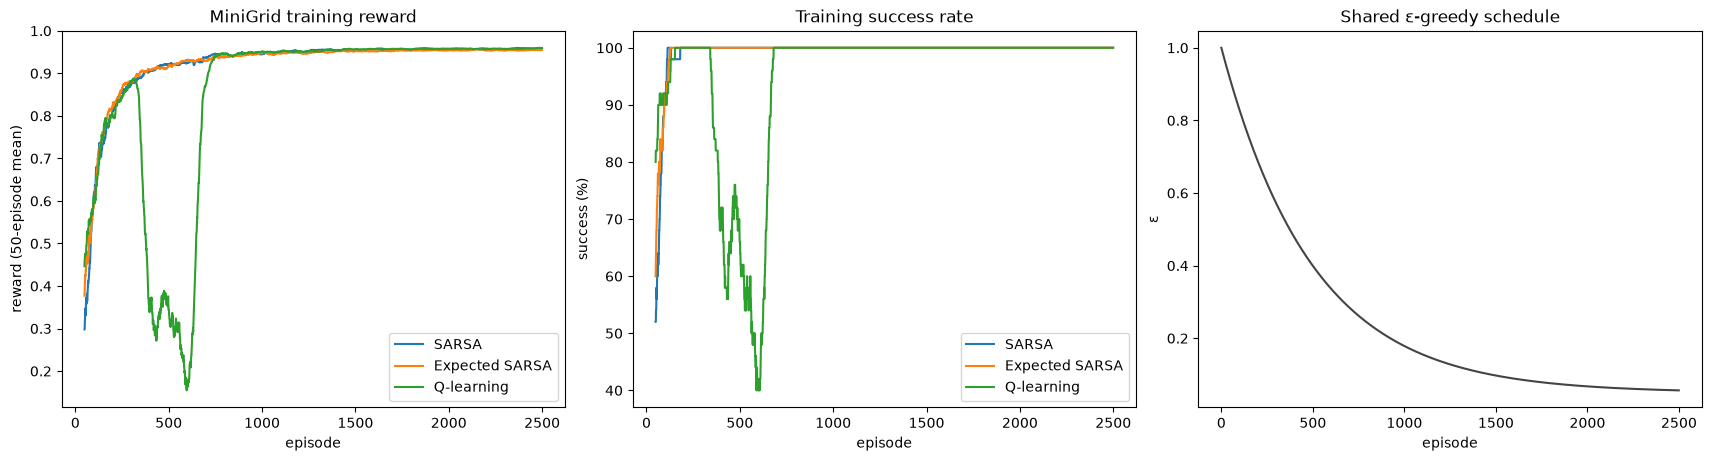

In [12]:
def moving_average(values, window=50):
    values = np.asarray(values, dtype=float)
    smoothed = np.convolve(values, np.ones(window) / window, mode="valid")
    return np.arange(window - 1, len(values)), smoothed


fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
for result in results:
    x_reward, smooth_reward = moving_average(result.episode_returns, window=50)
    x_success, smooth_success = moving_average(result.successes.astype(float), window=50)
    axes[0].plot(x_reward, smooth_reward, label=result.name)
    axes[1].plot(x_success, 100 * smooth_success, label=result.name)

axes[0].set_title("MiniGrid training reward")
axes[0].set_xlabel("episode")
axes[0].set_ylabel("reward (50-episode mean)")
axes[1].set_title("Training success rate")
axes[1].set_xlabel("episode")
axes[1].set_ylabel("success (%)")
axes[2].plot(results[0].epsilons, color="#444444")
axes[2].set_title("Shared ε-greedy schedule")
axes[2].set_xlabel("episode")
axes[2].set_ylabel("ε")
axes[0].legend()
axes[1].legend()
plt.show()

## 5. Greedy Evaluation

Training metrics include exploratory actions. Evaluation therefore sets `ε=0`, performs no updates, and measures each final greedy policy over 100 seeded episodes.

In [13]:
def greedy_rollout(q_values, seed=0, capture_frames=False, max_steps=256):
    env = make_env(render_mode="rgb_array" if capture_frames else None)
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    state = get_agent_state(env)
    total_reward = 0.0
    local_actions = []
    frames = [env.render().copy()] if capture_frames else []
    terminated = truncated = False

    for _ in range(max_steps):
        local_action = sample_epsilon_greedy(q_values[state], epsilon=0.0, rng=rng)
        _, reward, terminated, truncated, _ = env.step(int(NAV_ACTIONS[local_action]))
        state = get_agent_state(env)
        local_actions.append(local_action)
        total_reward += float(reward)
        if capture_frames:
            frames.append(env.render().copy())
        if terminated or truncated:
            break

    steps = env.unwrapped.step_count
    env.close()
    return {
        "reward": total_reward,
        "steps": steps,
        "success": bool(terminated and total_reward > 0),
        "actions": local_actions,
        "frames": frames,
    }


def evaluate_greedy_policy(q_values, episodes=100, seed=1000):
    rollouts = [greedy_rollout(q_values, seed=seed + episode) for episode in range(episodes)]
    return {
        "mean_reward": float(np.mean([item["reward"] for item in rollouts])),
        "mean_steps": float(np.mean([item["steps"] for item in rollouts])),
        "success_rate": float(np.mean([item["success"] for item in rollouts])),
    }


print(f"{'algorithm':>14} | {'mean reward':>11} | {'mean steps':>10} | {'success':>8}")
print("-" * 56)
for result in results:
    metrics = evaluate_greedy_policy(result.q_values)
    print(
        f"{result.name:>14} | {metrics['mean_reward']:>11.3f} | "
        f"{metrics['mean_steps']:>10.2f} | {100 * metrics['success_rate']:>7.1f}%"
    )

     algorithm | mean reward | mean steps |  success
--------------------------------------------------------
         SARSA |       0.961 |      11.00 |   100.0%
Expected SARSA |       0.958 |      12.00 |   100.0%
    Q-learning |       0.961 |      11.00 |   100.0%


### 5.1 Direction-dependent policy heatmaps

MiniGrid actions are relative to orientation, so one arrow map is not enough. Each panel fixes the agent direction and displays the greedy relative action (`↺`, `↻`, or `↑`) plus $\max_a Q(s,a)$ at every traversable position.

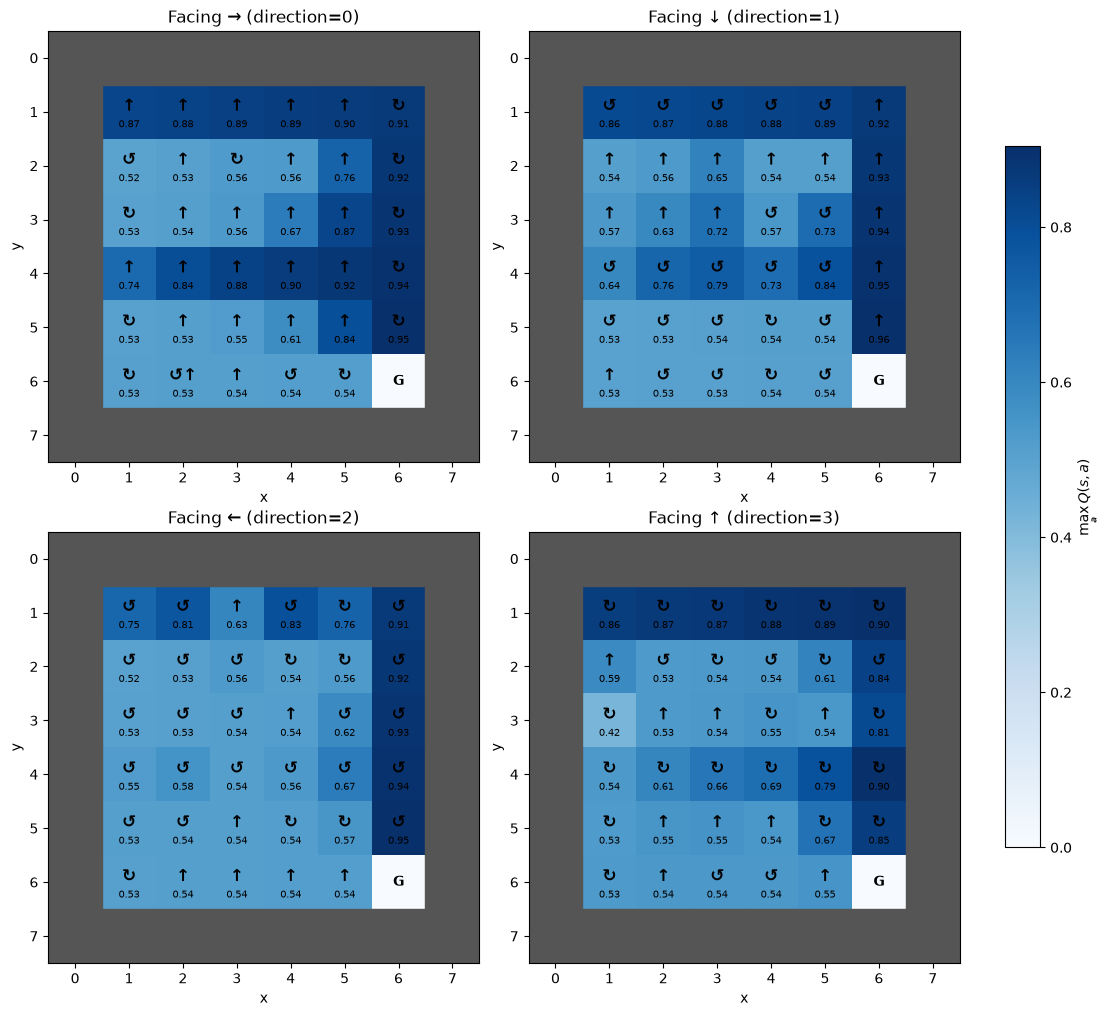

In [14]:
def plot_policy_for_direction(env, q_values, direction, ax, title):
    walls, goal = layout_from_env(env)
    width, height = env.unwrapped.width, env.unwrapped.height
    value_map = np.full((height, width), np.nan, dtype=float)

    for x in range(width):
        for y in range(height):
            if not walls[y, x]:
                value_map[y, x] = float(np.max(q_values[x, y, direction]))

    image = ax.imshow(np.ma.masked_invalid(value_map), cmap="Blues", origin="upper")
    for x in range(width):
        for y in range(height):
            if walls[y, x]:
                ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color="#555555"))
            elif (x, y) == goal:
                ax.text(x, y, "G", ha="center", va="center", weight="bold")
            else:
                action_values = q_values[x, y, direction]
                greedy = np.flatnonzero(np.isclose(action_values, np.max(action_values)))
                symbols = "".join(ACTION_SYMBOLS[action] for action in greedy)
                ax.text(x, y - 0.10, symbols, ha="center", va="center", fontsize=12, weight="bold")
                ax.text(x, y + 0.24, f"{np.max(action_values):.2f}", ha="center", va="center", fontsize=7)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    return image


q_learning_result = next(result for result in results if result.name == "Q-learning")
policy_env = make_env()
policy_env.reset(seed=SEED)
fig, axes = plt.subplots(2, 2, figsize=(11, 10), constrained_layout=True)
last_image = None
for direction, ax in enumerate(axes.flat):
    last_image = plot_policy_for_direction(
        policy_env,
        q_learning_result.q_values,
        direction,
        ax,
        title=f"Facing {DIRECTION_SYMBOLS[direction]} (direction={direction})",
    )
fig.colorbar(last_image, ax=axes, shrink=0.75, label="$\\max_a Q(s,a)$")
plt.show()
policy_env.close()

### 5.2 Learned Q-learning policy GIF

The final animation runs the greedy policy without learning. MiniGrid's native terminal reward is larger when the goal is reached quickly, so the displayed reward also summarizes path efficiency.

Actions: forward → forward → forward → forward → forward → right → forward → forward → forward → forward → forward
Reward=0.961, steps=11, success=True


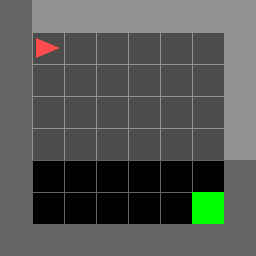

In [15]:
learned_rollout = greedy_rollout(
    q_learning_result.q_values,
    seed=2026,
    capture_frames=True,
)
learned_gif = ARTIFACT_DIR / "minigrid_q_learning.gif"
imageio.mimsave(learned_gif, learned_rollout["frames"], fps=5, loop=0)

action_sequence = [ACTION_NAMES[action] for action in learned_rollout["actions"]]
print("Actions:", " → ".join(action_sequence))
print(
    f"Reward={learned_rollout['reward']:.3f}, steps={learned_rollout['steps']}, "
    f"success={learned_rollout['success']}"
)
display(Image(filename=str(learned_gif)))

## 6. Supplement: TD Control in Gymnasium Taxi

Taxi is a useful second example because Gymnasium returns one integer state rather than an image or dictionary observation. The agent must navigate to a passenger, pick the passenger up, drive to the requested destination, and perform a legal drop-off. Its small state and action spaces make every action value representable in a Q-table.

Current Gymnasium releases provide **Taxi-v4**; older releases provide **Taxi-v3**. The version check below selects the available environment without changing the learning algorithm.

Environment: Taxi-v4
Observation space: Discrete(500)
Action space: Discrete(6)
Action mapping: {0: 'south', 1: 'north', 2: 'east', 3: 'west', 4: 'pickup', 5: 'dropoff'}
Encoded state: 309
Decoded state: {'taxi_row': 3, 'taxi_col': 0, 'passenger': 'Y', 'destination': 'G'}


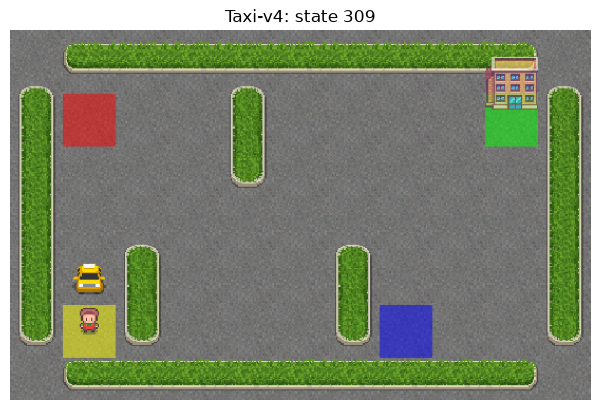

In [16]:
TAXI_ENV_NAME = "Taxi-v4" if "Taxi-v4" in gym.envs.registry else "Taxi-v3"
TAXI_ACTION_NAMES = (
    "south", "north", "east", "west", "pickup", "dropoff"
)
TAXI_LOCATION_NAMES = {0: "R", 1: "G", 2: "Y", 3: "B", 4: "inside taxi"}

taxi_preview_env = gym.make(TAXI_ENV_NAME, render_mode="rgb_array")
taxi_state, taxi_info = taxi_preview_env.reset(seed=SEED)
taxi_frame = taxi_preview_env.render()
taxi_row, taxi_col, passenger_location, destination = tuple(
    taxi_preview_env.unwrapped.decode(taxi_state)
)

print("Environment:", TAXI_ENV_NAME)
print("Observation space:", taxi_preview_env.observation_space)
print("Action space:", taxi_preview_env.action_space)
print("Action mapping:", dict(enumerate(TAXI_ACTION_NAMES)))
print("Encoded state:", taxi_state)
print(
    "Decoded state:",
    {
        "taxi_row": taxi_row,
        "taxi_col": taxi_col,
        "passenger": TAXI_LOCATION_NAMES[passenger_location],
        "destination": TAXI_LOCATION_NAMES[destination],
    },
)

plt.figure(figsize=(7.5, 4.8))
plt.imshow(taxi_frame)
plt.title(f"{TAXI_ENV_NAME}: state {taxi_state}")
plt.axis("off")
plt.show()
taxi_preview_env.close()

### 6.1 State encoding, actions, and rewards

Taxi has 500 states. Gymnasium combines four state variables into one integer:

$$
s = (((r \times 5 + c) \times 5 + p) \times 4 + d),
$$

where $(r,c)$ is the taxi position, $p$ is one of four landmarks or **inside taxi**, and $d$ is one of four destination landmarks. Calling **decode(state)** recovers these variables.

The six actions are south, north, east, west, pickup, and drop-off. Every time step gives $-1$, an illegal pickup or drop-off gives $-10$, and a correct drop-off gives $+20$ and terminates the episode. This reward structure asks the agent to learn both **what** to do and **how efficiently** to do it.

For Q-learning, the table has shape $500 \times 6$ and the update is unchanged:

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\left[R_{t+1} + \gamma\max_a Q(S_{t+1},a)-Q(S_t,A_t)\right].
$$

In [17]:
@dataclass
class TaxiTrainingResult:
    q_values: np.ndarray
    episode_returns: np.ndarray
    episode_lengths: np.ndarray
    successes: np.ndarray
    epsilons: np.ndarray


def train_taxi_q_learning(
    episodes=6000,
    alpha=0.15,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_end=0.05,
    seed=0,
):
    env = gym.make(TAXI_ENV_NAME)
    q_values = np.zeros((env.observation_space.n, env.action_space.n), dtype=float)
    episode_returns = np.zeros(episodes, dtype=float)
    episode_lengths = np.zeros(episodes, dtype=int)
    successes = np.zeros(episodes, dtype=bool)
    epsilons = np.zeros(episodes, dtype=float)
    rng = np.random.default_rng(seed)

    for episode in range(episodes):
        progress = episode / max(1, episodes - 1)
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-6.0 * progress)
        epsilons[episode] = epsilon
        state, _ = env.reset(seed=seed + episode)
        episode_steps = 0

        while True:
            episode_steps += 1
            action = sample_epsilon_greedy(q_values[state], epsilon, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)

            if terminated:
                td_target = float(reward)
            else:
                td_target = float(reward) + gamma * np.max(q_values[next_state])

            td_error = td_target - q_values[state, action]
            q_values[state, action] += alpha * td_error
            episode_returns[episode] += float(reward)

            if terminated or truncated:
                episode_lengths[episode] = episode_steps
                successes[episode] = bool(terminated and reward == 20)
                break

            state = next_state

    env.close()
    return TaxiTrainingResult(
        q_values, episode_returns, episode_lengths, successes, epsilons
    )


taxi_result = train_taxi_q_learning(seed=SEED)
print("Q-table shape:", taxi_result.q_values.shape)
print(f"Last-100 mean reward: {taxi_result.episode_returns[-100:].mean():.2f}")
print(f"Last-100 success rate: {100 * taxi_result.successes[-100:].mean():.1f}%")

Q-table shape: (500, 6)
Last-100 mean reward: 5.81
Last-100 success rate: 100.0%


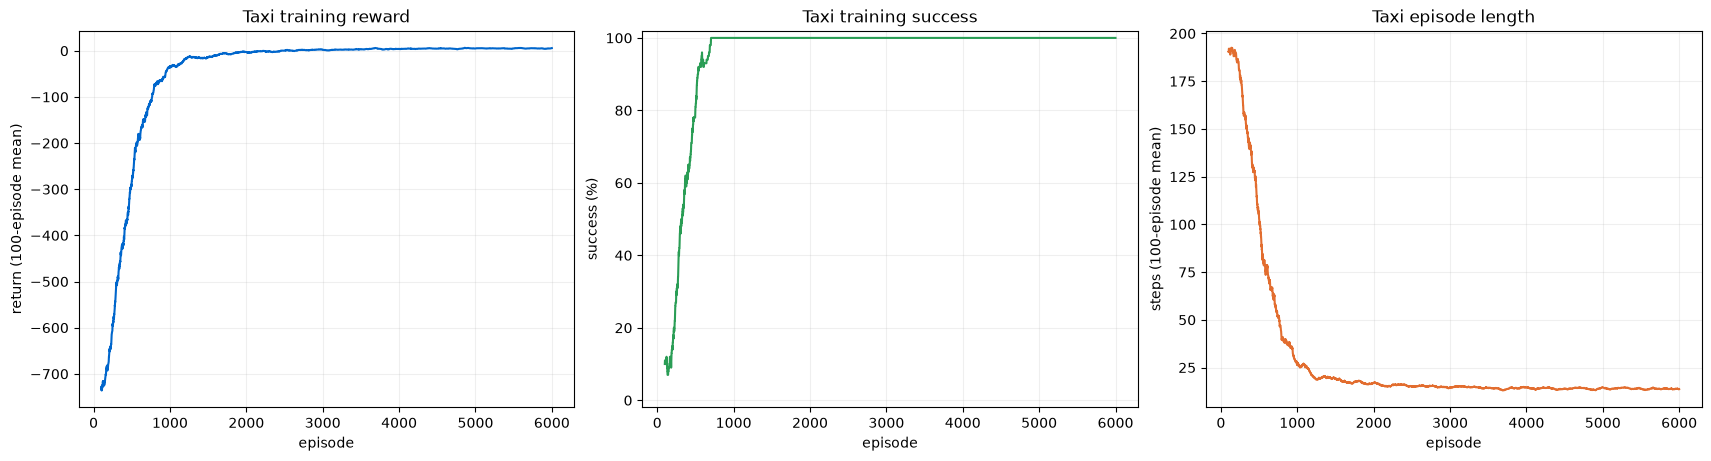

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
taxi_reward_x, taxi_reward_mean = moving_average(
    taxi_result.episode_returns, window=100
)
taxi_success_x, taxi_success_mean = moving_average(
    taxi_result.successes.astype(float), window=100
)
taxi_length_x, taxi_length_mean = moving_average(
    taxi_result.episode_lengths, window=100
)

axes[0].plot(taxi_reward_x, taxi_reward_mean, color="#0066cc")
axes[0].set_title("Taxi training reward")
axes[0].set_ylabel("return (100-episode mean)")
axes[1].plot(taxi_success_x, 100 * taxi_success_mean, color="#2a9d55")
axes[1].set_title("Taxi training success")
axes[1].set_ylabel("success (%)")
axes[1].set_ylim(-2, 102)
axes[2].plot(taxi_length_x, taxi_length_mean, color="#e26d2f")
axes[2].set_title("Taxi episode length")
axes[2].set_ylabel("steps (100-episode mean)")
for axis in axes:
    axis.set_xlabel("episode")
    axis.grid(alpha=0.2)
plt.show()

### 6.2 Greedy evaluation and rollout visualization

Training performance includes exploratory actions. To measure the learned policy itself, we set ε to zero, evaluate it on 100 independently seeded episodes, and animate one complete passenger delivery.

Greedy evaluation: mean reward=8.05, mean steps=12.95, success=100.0%
Actions: pickup → south → west → south → south → south → dropoff
Reward=14.0, steps=7, success=True


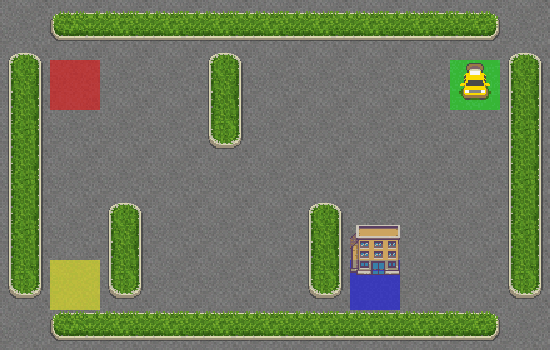

In [19]:
def taxi_greedy_rollout(q_values, seed=0, capture_frames=False):
    env = gym.make(
        TAXI_ENV_NAME,
        render_mode="rgb_array" if capture_frames else None,
    )
    state, _ = env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    frames = [env.render().copy()] if capture_frames else []
    actions = []
    total_reward = 0.0
    final_reward = 0.0
    terminated = truncated = False
    max_steps = env.spec.max_episode_steps or 200

    for _ in range(max_steps):
        action = sample_epsilon_greedy(q_values[state], epsilon=0.0, rng=rng)
        state, reward, terminated, truncated, _ = env.step(action)
        actions.append(action)
        total_reward += float(reward)
        final_reward = float(reward)
        if capture_frames:
            frames.append(env.render().copy())
        if terminated or truncated:
            break

    env.close()
    return {
        "reward": total_reward,
        "steps": len(actions),
        "success": bool(terminated and final_reward == 20),
        "actions": actions,
        "frames": frames,
    }


taxi_evaluations = [
    taxi_greedy_rollout(taxi_result.q_values, seed=10_000 + episode)
    for episode in range(100)
]
print(
    "Greedy evaluation: "
    f"mean reward={np.mean([item['reward'] for item in taxi_evaluations]):.2f}, "
    f"mean steps={np.mean([item['steps'] for item in taxi_evaluations]):.2f}, "
    f"success={100 * np.mean([item['success'] for item in taxi_evaluations]):.1f}%"
)

taxi_demo = taxi_greedy_rollout(
    taxi_result.q_values, seed=2026, capture_frames=True
)
taxi_gif = ARTIFACT_DIR / "taxi_q_learning.gif"
imageio.mimsave(taxi_gif, taxi_demo["frames"], fps=3, loop=0)
taxi_action_sequence = [TAXI_ACTION_NAMES[action] for action in taxi_demo["actions"]]
print("Actions:", " → ".join(taxi_action_sequence))
print(
    f"Reward={taxi_demo['reward']:.1f}, steps={taxi_demo['steps']}, "
    f"success={taxi_demo['success']}"
)
display(Image(filename=str(taxi_gif)))

## 7. Reward Shaping for Sparse-Reward Tasks

The Empty and Taxi tasks provide feedback soon enough for tabular exploration. **MiniGrid-BlockedUnlockPickup-v0** is harder: the agent must move a blocking ball, collect a matching key, unlock a door, and finally pick up a box. The native environment gives a positive reward only when the entire sequence succeeds.

With only terminal feedback, a random trajectory is unlikely to discover every prerequisite in the correct order. Reward shaping adds intermediate feedback so that temporal-difference updates can assign credit to useful progress.

We use one fixed layout seed in this section. Holding the map constant isolates the effect of the reward signal: the sparse and shaped agents use the same state representation, Q-learning update, action space, exploration schedule, and number of episodes.

Environment: MiniGrid-BlockedUnlockPickup-v0
Mission: pick up the purple box
Action mapping: {0: 'left', 1: 'right', 2: 'forward', 3: 'pickup', 4: 'drop', 5: 'toggle'}
 key: position=(4, 1), color=blue
ball: position=(4, 4), color=red
door: position=(5, 4), color=blue, locked=True, open=False
 box: position=(7, 4), color=purple


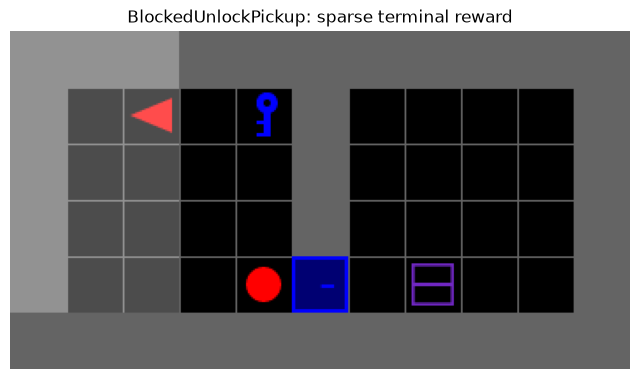

In [20]:
SHAPING_ENV_NAME = "MiniGrid-BlockedUnlockPickup-v0"
SHAPING_LAYOUT_SEED = SEED
SHAPING_ACTIONS = np.array([0, 1, 2, 3, 4, 5], dtype=int)
SHAPING_ACTION_NAMES = (
    "left", "right", "forward", "pickup", "drop", "toggle"
)
SHAPING_STAGE_NAMES = {
    0: "clear blocking ball",
    1: "drop ball safely",
    2: "collect key",
    3: "unlock door",
    4: "collect box",
    5: "complete",
    6: "box destroyed",
}


def scan_task_objects(env):
    objects = {}
    grid = env.unwrapped.grid
    for x in range(grid.width):
        for y in range(grid.height):
            obj = grid.get(x, y)
            if obj is not None and obj.type in {"ball", "key", "door", "box"}:
                objects[obj.type] = (x, y, obj)
    return objects


shaping_preview_env = gym.make(SHAPING_ENV_NAME, render_mode="rgb_array")
shaping_preview_env.reset(seed=SHAPING_LAYOUT_SEED)
shaping_objects = scan_task_objects(shaping_preview_env)
print("Environment:", SHAPING_ENV_NAME)
print("Mission:", shaping_preview_env.unwrapped.mission)
print("Action mapping:", dict(enumerate(SHAPING_ACTION_NAMES)))
for object_type, (x, y, obj) in shaping_objects.items():
    status = ""
    if object_type == "door":
        status = f", locked={obj.is_locked}, open={obj.is_open}"
    print(f"{object_type:>4}: position=({x}, {y}), color={obj.color}{status}")

plt.figure(figsize=(8, 4.5))
plt.imshow(shaping_preview_env.render())
plt.title("BlockedUnlockPickup: sparse terminal reward")
plt.axis("off")
plt.show()
shaping_preview_env.close()

### 7.1 A stage-aware state and shaping potential

The state records the current subgoal stage, agent position and direction, the object directly ahead, the carried object, and whether the ball can be dropped safely. This is still a tabular representation; it simply exposes task-relevant information that the partially observable image alone would hide.

We assign a scalar potential $\Phi(s)$ that increases when the agent advances through the prerequisite stages and when it approaches the current subgoal. The shaped reward is

$$
R'_{t+1}=R_{t+1}+\gamma\Phi(S_{t+1})-\Phi(S_t).
$$

The Q-learning update uses $R'$ during training, but evaluation counts only the **native environment reward**. Therefore, an agent cannot be declared successful merely by collecting shaping rewards.

Reward design must be audited carefully. Repeated bonuses can create reward loops, oversized bonuses can replace the real objective, and state features that omit progress flags can make the task non-Markov. Here, each stage is part of the state and the potential difference rewards transitions rather than repeatedly paying for the same event.

In [21]:
@dataclass
class RewardShapingResult:
    name: str
    q_values: dict
    learning_returns: np.ndarray
    environment_returns: np.ndarray
    episode_lengths: np.ndarray
    successes: np.ndarray


def shaping_state_and_potential(env, terminated=False):
    base_env = env.unwrapped
    objects = scan_task_objects(env)
    carrying = base_env.carrying.type if base_env.carrying is not None else "none"
    door_x, door_y, door = objects["door"]
    blocking_position = (door_x - 1, door_y)
    ball = objects.get("ball")
    key = objects.get("key")
    box = objects.get("box")

    if terminated or carrying == "box":
        stage, target = 5, tuple(base_env.agent_pos)
    elif box is None:
        stage, target = 6, tuple(base_env.agent_pos)
    elif ball is not None and ball[:2] == blocking_position:
        stage, target = 0, ball[:2]
    elif carrying == "ball":
        stage, target = 1, tuple(base_env.front_pos)
    elif door.is_locked and carrying != "key":
        stage, target = 2, key[:2]
    elif door.is_locked:
        stage, target = 3, (door_x, door_y)
    else:
        stage, target = 4, box[:2]

    front_position = tuple(map(int, base_env.front_pos))
    front_object = base_env.grid.get(*front_position)
    front_type = "empty" if front_object is None else front_object.type
    safe_drop = bool(
        stage == 1
        and front_object is None
        and front_position != blocking_position
    )
    agent_x, agent_y = map(int, base_env.agent_pos)
    target_x, target_y = map(int, target)
    distance = abs(target_x - agent_x) + abs(target_y - agent_y)

    state = (
        stage,
        agent_x,
        agent_y,
        int(base_env.agent_dir),
        front_type,
        carrying,
        safe_drop,
    )
    potential = (
        -20.0
        if stage == 6
        else 5.0 * stage - 0.2 * distance + float(safe_drop)
    )
    return state, potential, stage


def train_blocked_q_learning(
    use_shaping,
    episodes=500,
    alpha=0.25,
    gamma=0.99,
    max_steps=200,
    seed=SEED,
):
    env = gym.make(SHAPING_ENV_NAME)
    q_values = {}
    learning_returns = np.zeros(episodes, dtype=float)
    environment_returns = np.zeros(episodes, dtype=float)
    episode_lengths = np.zeros(episodes, dtype=int)
    successes = np.zeros(episodes, dtype=bool)
    rng = np.random.default_rng(seed)

    for episode in range(episodes):
        env.reset(seed=SHAPING_LAYOUT_SEED)
        state, potential, _ = shaping_state_and_potential(env)
        progress = episode / max(1, episodes - 1)
        epsilon = 0.03 + 0.97 * np.exp(-7.0 * progress)
        last_environment_reward = 0.0
        terminated = truncated = False

        for step in range(1, max_steps + 1):
            q_values.setdefault(state, np.zeros(len(SHAPING_ACTIONS), dtype=float))
            local_action = sample_epsilon_greedy(q_values[state], epsilon, rng)
            _, environment_reward, terminated, truncated, _ = env.step(
                int(SHAPING_ACTIONS[local_action])
            )
            next_state, next_potential, _ = shaping_state_and_potential(
                env, terminated=terminated
            )
            q_values.setdefault(
                next_state, np.zeros(len(SHAPING_ACTIONS), dtype=float)
            )

            shaping_reward = (
                gamma * next_potential - potential if use_shaping else 0.0
            )
            learning_reward = float(environment_reward) + shaping_reward
            td_target = (
                learning_reward
                if terminated
                else learning_reward + gamma * np.max(q_values[next_state])
            )
            td_error = td_target - q_values[state][local_action]
            q_values[state][local_action] += alpha * td_error

            learning_returns[episode] += learning_reward
            environment_returns[episode] += float(environment_reward)
            last_environment_reward = float(environment_reward)
            state, potential = next_state, next_potential

            if terminated or truncated:
                break

        episode_lengths[episode] = step
        successes[episode] = bool(terminated and last_environment_reward > 0)

    env.close()
    return RewardShapingResult(
        "Potential-shaped reward" if use_shaping else "Sparse reward",
        q_values,
        learning_returns,
        environment_returns,
        episode_lengths,
        successes,
    )

          Sparse reward: last-100 success=  0.0% | native reward=0.000 | steps=200.0
Potential-shaped reward: last-100 success=100.0% | native reward=0.956 | steps=28.1


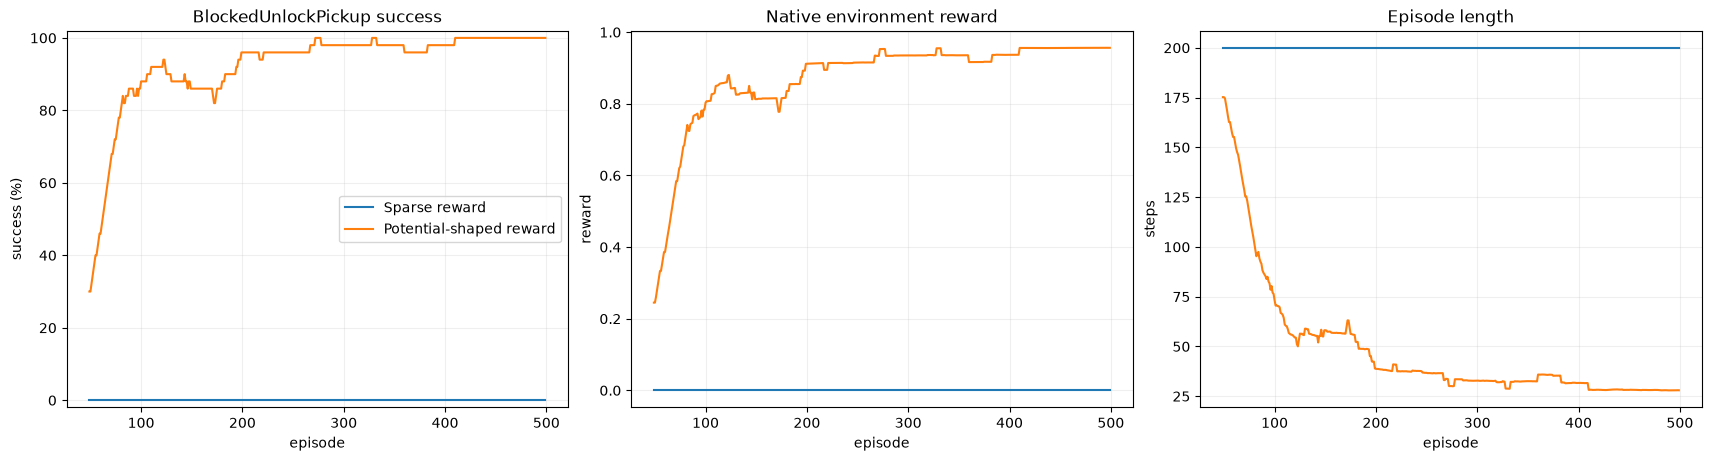

In [22]:
sparse_result = train_blocked_q_learning(use_shaping=False)
shaped_result = train_blocked_q_learning(use_shaping=True)
shaping_results = [sparse_result, shaped_result]

for result in shaping_results:
    print(
        f"{result.name:>23}: "
        f"last-100 success={100 * result.successes[-100:].mean():5.1f}% | "
        f"native reward={result.environment_returns[-100:].mean():.3f} | "
        f"steps={result.episode_lengths[-100:].mean():.1f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
for result in shaping_results:
    success_x, success_mean = moving_average(
        result.successes.astype(float), window=50
    )
    reward_x, reward_mean = moving_average(
        result.environment_returns, window=50
    )
    length_x, length_mean = moving_average(result.episode_lengths, window=50)
    axes[0].plot(success_x, 100 * success_mean, label=result.name)
    axes[1].plot(reward_x, reward_mean, label=result.name)
    axes[2].plot(length_x, length_mean, label=result.name)

axes[0].set_title("BlockedUnlockPickup success")
axes[0].set_ylabel("success (%)")
axes[0].set_ylim(-2, 102)
axes[1].set_title("Native environment reward")
axes[1].set_ylabel("reward")
axes[2].set_title("Episode length")
axes[2].set_ylabel("steps")
for axis in axes:
    axis.set_xlabel("episode")
    axis.grid(alpha=0.2)
axes[0].legend()
plt.show()

### 7.2 Evaluate with the original task reward

A shaped training return is not proof that the task was solved. We therefore disable exploration, run 20 episodes, and count success only when MiniGrid emits a positive native reward. The animation shows one complete greedy rollout and makes the learned prerequisite sequence directly inspectable.

Success: 20/20
Mean native reward: 0.958
Mean episode length: 27.0
Stage progression: clear blocking ball → drop ball safely → collect key → unlock door → collect box → complete
First rollout actions: left → forward → forward → forward → left → forward → pickup → left → drop → right → forward → left → forward → forward → pickup → right → right → forward → forward → left → toggle → forward → forward → left → drop → right → pickup


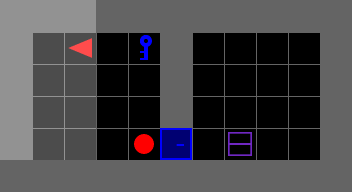

In [23]:
def evaluate_blocked_policy(
    q_values,
    episodes=20,
    max_steps=200,
    seed=SEED,
    capture_first=True,
):
    env = gym.make(
        SHAPING_ENV_NAME,
        render_mode="rgb_array" if capture_first else None,
    )
    rng = np.random.default_rng(seed)
    successes = []
    episode_rewards = []
    episode_lengths = []
    frames = []
    first_actions = []
    first_stages = []

    for episode in range(episodes):
        env.reset(seed=SHAPING_LAYOUT_SEED)
        state, _, stage = shaping_state_and_potential(env)
        total_reward = 0.0
        final_reward = 0.0
        terminated = truncated = False
        if capture_first and episode == 0:
            frames.append(env.render().copy())
            first_stages.append(stage)

        for step in range(1, max_steps + 1):
            action_values = q_values.get(state, np.zeros(len(SHAPING_ACTIONS)))
            local_action = sample_epsilon_greedy(
                action_values, epsilon=0.0, rng=rng
            )
            _, reward, terminated, truncated, _ = env.step(
                int(SHAPING_ACTIONS[local_action])
            )
            state, _, stage = shaping_state_and_potential(
                env, terminated=terminated
            )
            total_reward += float(reward)
            final_reward = float(reward)

            if capture_first and episode == 0:
                frames.append(env.render().copy())
                first_actions.append(local_action)
                first_stages.append(stage)
            if terminated or truncated:
                break

        successes.append(bool(terminated and final_reward > 0))
        episode_rewards.append(total_reward)
        episode_lengths.append(step)

    env.close()
    return {
        "successes": np.asarray(successes),
        "rewards": np.asarray(episode_rewards),
        "lengths": np.asarray(episode_lengths),
        "frames": frames,
        "first_actions": first_actions,
        "first_stages": first_stages,
    }


blocked_evaluation = evaluate_blocked_policy(shaped_result.q_values)
blocked_gif = ARTIFACT_DIR / "minigrid_reward_shaping.gif"
imageio.mimsave(
    blocked_gif, blocked_evaluation["frames"], fps=5, loop=0
)
stage_sequence = [
    SHAPING_STAGE_NAMES[stage]
    for index, stage in enumerate(blocked_evaluation["first_stages"])
    if index == 0 or stage != blocked_evaluation["first_stages"][index - 1]
]
action_sequence = [
    SHAPING_ACTION_NAMES[action]
    for action in blocked_evaluation["first_actions"]
]
print(
    f"Success: {blocked_evaluation['successes'].sum()}/"
    f"{len(blocked_evaluation['successes'])}"
)
print(f"Mean native reward: {blocked_evaluation['rewards'].mean():.3f}")
print(f"Mean episode length: {blocked_evaluation['lengths'].mean():.1f}")
print("Stage progression:", " → ".join(stage_sequence))
print("First rollout actions:", " → ".join(action_sequence))
display(Image(filename=str(blocked_gif)))

## Conclusions

In this lab, you completed a full tabular TD-learning workflow using MiniGrid and Taxi:

- Inspected Gymnasium observation, action, termination, and rendering interfaces
- Represented MiniGrid navigation states with position and direction
- Evaluated a fixed policy with TD(0)
- Implemented SARSA, Expected SARSA, and Q-learning under matched conditions
- Compared on-policy and off-policy bootstrap targets
- Compared training curves, greedy performance, values, policies, and animated rollouts
- Decoded Taxi's discrete states and trained a successful passenger-delivery policy
- Compared sparse and potential-shaped rewards on BlockedUnlockPickup
- Evaluated shaped learning using only the original environment reward

The central TD idea is to **learn from a reward plus a current estimate of what comes next**. SARSA, Expected SARSA, and Q-learning differ in how they construct that next-state estimate, while the Q-table keeps every learned state–action value explicit and directly inspectable.

---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.  
SPDX-License-Identifier: MIT